# Codon-conditioned backbone signal: robustness analysis

This notebook stress-tests the codon-pair rejections shown in Figure 1. For every pair
flagged significant by at least one two-sample statistic, it asks: how many of the most
influential observations would need to be removed before the rejection disappears
(adversarial breakdown-k), and does the same rejection survive under label-randomized
null controls that preserve every observation's (phi, psi)?

Everything below is derived live from the same `cc-pvals.csv` files Figure 1 loads --
re-running the upstream pipeline and then re-running this notebook regenerates every
number here with no manual step.

In [46]:
import json
import sys
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from tqdm.auto import tqdm

sys.path.insert(0, ".")

from _pnas2026_common import LABELLED_TAGS, compute_bh_rejections, load_all_pvals

from pp5.analysis import DSSP_TO_SS_TYPE
from pp5.dihedral import flat_torus_distance
from pp5.distributions.kde import gaussian_kernel
from pp5.stats.breakdown import breakdown_k_kde, breakdown_k_mmd
from pp5.stats.controls import (
    gen_aa_ss_control_replicates,
    gen_pooled_shuffle_replicates,
    null_control_summary,
)

SEED = 12345
FDR = 0.05
K_PERM = (
    5000  # permutations for real-pair baseline p-values and breakdown-k checkpoints
)
K_CTRL = 2000  # permutations for control-replicate baseline/breakdown checkpoints
N_CONTROL_REPLICATES = 30

# Number of joblib worker processes for arms with no internal parallelism of their
# own (MMD, torus-W2). The KDE arms are deliberately NOT parallelized this way:
# their own permutation test is already BLAS-batched (kde_2d_slab_stacks /
# kde_l1_permutation_test_from_slabs process batch_size=1000 permutations per BLAS
# call), so adding outer-loop worker processes on top would oversubscribe the same
# cores rather than speed anything up. MMD's permutation loop is a plain
# per-permutation Python loop (mmd_permutation_test_from_kernel) and torus's R call
# runs with NC_geodesic=1 -- neither has any internal parallelism to conflict with,
# confirmed by inspection and a joblib smoke test (byte-identical stat/pval to a
# sequential run, ~2x speedup on 4 pairs with n_jobs=4).
N_JOBS = 4

# If True, always recompute every arm live even when a matching CSV already exists
# under OUT_DIR. Leave False to reuse a previous run's results; set True (or just
# delete the specific arm's CSV) when the upstream pvals/dataset actually change.
FORCE_RECOMPUTE = False

# The 5 statistics with an adversarial breakdown-k procedure. All 5 -- including
# torus-W2 -- go through the exact same compute/cache/parallelize pipeline below;
# there is no separate "fast vs. slow" or "live vs. cached-from-Alex" code path.
BREAKDOWN_ARMS = [
    "kde-l1(bw=10.0)",
    # "kde-l1(bw=CV)",
    "mmd(unbiased)",
    # "mmd(biased)",
    "w2torus(4-fixed)",
]

# Every CSV this notebook writes (one per breakdown-k arm, its breakdown-set
# sidecar, the joined table, and the combined breakdown-set/provenance table)
# lands here, keyed by name -- re-running the notebook reuses them (per
# FORCE_RECOMPUTE above) instead of recomputing from scratch.
OUT_DIR = Path("../../out/pnas-2026/robustness").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Load p-values

Same registry and loader Figure 1 uses (`_pnas2026_common.py`), so this notebook can never
diverge on which runs or thresholds are in play.

In [47]:
df_all_pvals = load_all_pvals(LABELLED_TAGS)
df_rejections = compute_bh_rejections(df_all_pvals, fdr=FDR)
real_rejections = df_rejections[
    (df_rejections["codon_randomization"] == "none")
    & (df_rejections["stat_test"].isin(BREAKDOWN_ARMS))
].reset_index(drop=True)
real_rejections

,stat_test,codon_randomization,SS,n_hypotheses,fdr,bh_pvalue_threshold,n_rejected,rejected_pairs
0,w2torus(4-fixed),none,HELIX,87,0.05,0.002299,4,"[L-CTC:L-TTG, L-CTC:L-CTG, L-CTC:L-CTT, R-AGG:..."
1,w2torus(4-fixed),none,OTHER,87,0.05,0.000000,0,[]
2,w2torus(4-fixed),none,SHEET,87,0.05,0.000000,0,[]
3,w2torus(4-fixed),none,TURN,87,0.05,0.000575,1,[A-GCG:A-GCT]
4,kde-l1(bw=10.0),none,HELIX,87,0.05,0.001149,2,"[L-CTC:L-TTG, L-CTC:L-CTG]"
5,kde-l1(bw=10.0),none,OTHER,87,0.05,0.000000,0,[]
6,kde-l1(bw=10.0),none,SHEET,87,0.05,0.000000,0,[]
7,kde-l1(bw=10.0),none,TURN,87,0.05,0.001149,2,"[P-CCC:P-CCG, A-GCG:A-GCT]"
8,mmd(unbiased),none,HELIX,87,0.05,0.001149,2,"[L-CTC:L-TTG, L-CTC:L-CTG]"
9,mmd(unbiased),none,OTHER,87,0.05,0.000000,0,[]


## Load raw inputs

The pvals CSVs only carry aggregated statistics per codon pair; the breakdown-k and
provenance analysis below needs the underlying per-position data: the aggregated
dataset, the cross-validated KDE bandwidths (for the KDE-CV arm), and the raw
per-structure records (for PDB provenance -- loaded eagerly here so each arm can
resolve its own breakdown-set rows immediately as it computes, rather than needing a
separate pass over a saved index of removed observations afterward).

In [48]:
DATASET_PATH = Path(
    "../../out/prec-collected/20211001_124553-aida-ex_EC-src_EC/results/"
    "pointwise_cdist-natcom/_intermediate_/dataset.csv"
).resolve()
CV_BANDWIDTH_PATH = Path(
    "../../out/pnas-2026/bandwidth_cv/kernel_bandwidths.csv"
).resolve()
PROVENANCE_PATH = Path(
    "../../out/prec-collected/20211001_124553-aida-ex_EC-src_EC/data-precs.csv"
).resolve()

assert DATASET_PATH.is_file(), DATASET_PATH
assert CV_BANDWIDTH_PATH.is_file(), CV_BANDWIDTH_PATH
assert PROVENANCE_PATH.is_file(), PROVENANCE_PATH

df_dataset = pd.read_csv(DATASET_PATH)
if "AA" not in df_dataset.columns:
    df_dataset["AA"] = df_dataset["codon"].str.split("-").str[0]

df_cv_bandwidth = pd.read_csv(CV_BANDWIDTH_PATH).set_index(["codon", "ss"])[
    "sigma_cv_deg"
]

# Raw per-structure records, for the breakdown-set/provenance join further down.
df_data_precs = pd.read_csv(
    PROVENANCE_PATH,
    usecols=["pdb_id", "unp_id", "res_id", "unp_idx", "phi", "psi", "secondary"],
    low_memory=False,
)
# Consolidate DSSP codes with the same mapping the main pipeline uses, so a
# position's provenance is restricted to the structures that actually belong to
# the SS class being reported -- a residue can legitimately have structures in
# more than one SS class (Section 0(a) of the revision plan: different PDB
# structures can assign a residue different DSSP secondary structure), and
# pooling across SS would blend distinct conformational states into a
# meaningless average.
df_data_precs["condition_group"] = df_data_precs["secondary"].map(DSSP_TO_SS_TYPE)
data_precs_by_position = (
    df_data_precs.dropna(subset=["unp_idx", "condition_group"])
    .assign(unp_idx=lambda d: d["unp_idx"].astype(int))
    .groupby(["unp_id", "unp_idx", "condition_group"])
)

# (unp_id, unp_idx, SS) -> list of "pdb_id,res_id" strings.
provenance: dict[tuple[str, int, str], list[str]] = {}
_dp_valid = df_data_precs.dropna(subset=["unp_idx", "condition_group"])
for _pdb_id, _unp_id, _res_id, _unp_idx, _ss in zip(
    _dp_valid["pdb_id"],
    _dp_valid["unp_id"],
    _dp_valid["res_id"],
    _dp_valid["unp_idx"],
    _dp_valid["condition_group"],
):
    provenance.setdefault((_unp_id, int(_unp_idx), _ss), []).append(
        f"{_pdb_id},{_res_id}"
    )

## Determine candidate pairs

A pair is a candidate for breakdown-k if at least one of the 5 statistics above rejects
it in the real data, at that statistic's own BH threshold. This replaces any fixed pair
list: a future rerun with different p-values changes the candidate set automatically.
`df_candidate_pairs` below also records which specific statistics rejected each pair,
sorted by how many did (descending) -- saved as `candidate_pairs.csv`.

In [49]:
candidate_pairs = sorted(
    {
        (row.SS, pair)
        for row in real_rejections.itertuples()
        for pair in row.rejected_pairs
    }
)
print(f"{len(candidate_pairs)} candidate pairs:")
for ss, pair in candidate_pairs:
    print(f"  {ss}  {pair}")

# Sanity check against the historical stress-test set documented in the revision plan
# (Section 4): the same union should still appear, since these pvals are the ones that
# set produced.
HISTORICAL_UNION = {
    ("HELIX", "L-CTC:L-TTG"),
    ("HELIX", "L-CTC:L-CTG"),
    ("HELIX", "L-CTC:L-CTT"),
    ("HELIX", "R-AGG:R-CGA"),
    ("TURN", "A-GCG:A-GCT"),
    ("TURN", "P-CCC:P-CCG"),
}
missing = HISTORICAL_UNION - set(candidate_pairs)
assert not missing, (
    f"Historical stress-test pairs missing from the candidate set: {missing}"
)

# Which statistics rejected each candidate pair, for the table below -- restricted
# to BREAKDOWN_ARMS (the same set that defines candidate_pairs itself), so a pair's
# tests_rejected always lists at least one entry.
tests_rejected_by_pair: dict[tuple[str, str], list[str]] = {
    (ss, pair): [] for ss, pair in candidate_pairs
}
for row in real_rejections.itertuples():
    for pair in row.rejected_pairs:
        tests_rejected_by_pair[(row.SS, pair)].append(row.stat_test)

df_candidate_pairs = pd.DataFrame(
    [
        dict(SS=ss, pair=pair, tests_rejected=tests_rejected_by_pair[(ss, pair)])
        for ss, pair in candidate_pairs
    ]
)
df_candidate_pairs["n_tests_rejected"] = df_candidate_pairs["tests_rejected"].apply(len)
df_candidate_pairs = (
    df_candidate_pairs.sort_values(
        ["n_tests_rejected", "SS", "pair"], ascending=[False, True, True]
    )
    .drop(columns="n_tests_rejected")
    .reset_index(drop=True)
)
df_candidate_pairs.to_csv(OUT_DIR / "candidate_pairs.csv", index=False)
df_candidate_pairs

6 candidate pairs:
  HELIX  L-CTC:L-CTG
  HELIX  L-CTC:L-CTT
  HELIX  L-CTC:L-TTG
  HELIX  R-AGG:R-CGA
  TURN  A-GCG:A-GCT
  TURN  P-CCC:P-CCG


,SS,pair,tests_rejected
0,HELIX,L-CTC:L-CTG,"[w2torus(4-fixed), kde-l1(bw=10.0), mmd(unbias..."
1,HELIX,L-CTC:L-TTG,"[w2torus(4-fixed), kde-l1(bw=10.0), mmd(unbias..."
2,TURN,A-GCG:A-GCT,"[w2torus(4-fixed), kde-l1(bw=10.0), mmd(unbias..."
3,TURN,P-CCC:P-CCG,"[kde-l1(bw=10.0), mmd(unbiased)]"
4,HELIX,L-CTC:L-CTT,[w2torus(4-fixed)]
5,HELIX,R-AGG:R-CGA,[w2torus(4-fixed)]


## Shared helpers

`codon_angles` extracts one codon's (phi, psi) points (in radians) for a secondary-structure
class, plus the (unp_id, unp_idx) key of each point (needed later to trace adversarially-removed
points back to PDB structures). `k_grid_for` is the adversarial-removal checkpoint schedule,
used identically by every arm below. `circular_mean_deg`/`circular_std_deg` and
`resolve_breakdown_set_rows` expand one pair's adversarial-removal log into human-readable
breakdown-set rows (PDB provenance, aggregated angle) -- called directly inside each arm's own
per-pair computation, not as a separate downstream pass.

In [50]:
def codon_angles(
    df: pd.DataFrame, ss: str, codon: str
) -> tuple[np.ndarray, np.ndarray]:
    """Radian (phi, psi) points and (unp_id, unp_idx) keys for one (SS, codon) group.

    :param df: Dataset with columns `condition_group`, `codon`, `phi`, `psi`, `unp_id`,
        `unp_idx`.
    :param ss: Secondary-structure class, e.g. `"HELIX"`.
    :param codon: Codon label, e.g. `"L-CTC"`.
    :return: `(n, 2)` radian phi/psi array, `(n, 2)` object array of (unp_id, unp_idx).
    """
    sub = df[(df["condition_group"] == ss) & (df["codon"] == codon)]
    points = np.deg2rad(sub[["phi", "psi"]].to_numpy())
    keys = sub[["unp_id", "unp_idx"]].to_numpy()
    return points, keys


def k_grid_for(n_min: int) -> list[int]:
    """Adaptive breakdown-k checkpoint grid, capped so the smaller group keeps >= 2 points.

    :param n_min: Size of the smaller of the two groups being compared.
    :return: Sorted list of checkpoint values, each `<= n_min - 2`.
    """
    k_cap = min(40, max(5, int(np.ceil(0.05 * n_min))))
    grid = sorted({0, 1, 2, 3, 5, 8, 12, 20, k_cap})
    return [k for k in grid if k <= n_min - 2]


def circular_mean_deg(deg: np.ndarray) -> float:
    """Circular mean of angles given in degrees.

    :param deg: Array of angles in degrees.
    :return: Circular mean, in degrees.
    """
    rad = np.deg2rad(deg)
    return float(np.rad2deg(np.arctan2(np.sin(rad).mean(), np.cos(rad).mean())))


def circular_std_deg(deg: np.ndarray) -> float:
    """Circular standard deviation (Mardia) of angles given in degrees.

    :param deg: Array of angles in degrees.
    :return: Circular standard deviation, in degrees.
    """
    rad = np.deg2rad(deg)
    resultant_length = np.hypot(np.cos(rad).mean(), np.sin(rad).mean())
    resultant_length = min(max(resultant_length, 1e-12), 1.0)
    return float(np.rad2deg(np.sqrt(-2.0 * np.log(resultant_length))))


def resolve_breakdown_set_rows(
    ss: str,
    pair: str,
    statistic: str,
    breakdown_k,
    removed_log: list[tuple[str, int, float]],
    keys1: np.ndarray,
    keys2: np.ndarray,
    codon1: str,
    codon2: str,
) -> list[dict]:
    """Expand one (pair, statistic)'s adversarial-removal log into breakdown-set rows.

    Joins each adversarially-removed observation back to the raw per-structure
    records: which PDB structures support that (unp_id, unp_idx) position (within
    this pair's own SS class), and how tightly do they agree (circular mean and
    standard deviation of phi, psi across structures)? Shows the full breakdown-set
    when the pair actually broke down (`breakdown_k` observations); otherwise (a
    "robust" pair that never broke within the tested k-grid) shows the top 5 most
    influential points as a representative sample.

    :param ss: Secondary-structure class, e.g. `"HELIX"`.
    :param pair: `"<codon1>:<codon2>"` label.
    :param statistic: Arm name, e.g. `"mmd(unbiased)"`.
    :param breakdown_k: Smallest k that broke significance (`0` if already not
        significant at the baseline check), `None`/NaN if it never broke down
        within the tested k-grid.
    :param removed_log: `(side, local_idx, drop)` tuples in removal order, as
        returned by `greedy_breakdown_k`/`breakdown_torus`.
    :param keys1: `(n1, 2)` object array of (unp_id, unp_idx) for group 1.
    :param keys2: `(n2, 2)` object array of (unp_id, unp_idx) for group 2.
    :param codon1: First codon label.
    :param codon2: Second codon label.
    :return: One row per shown breakdown-set entry.
    """
    n_show = int(breakdown_k) if pd.notna(breakdown_k) else min(5, len(removed_log))

    rows = []
    for rank, (side, local_idx, drop) in enumerate(removed_log[:n_show], start=1):
        codon = codon1 if side == "X" else codon2
        unp_id, unp_idx = (keys1 if side == "X" else keys2)[local_idx]
        unp_idx = int(unp_idx)
        try:
            structures = data_precs_by_position.get_group((unp_id, unp_idx, ss))
        except KeyError:
            structures = df_data_precs.iloc[0:0]

        rows.append(
            dict(
                SS=ss,
                pair=pair,
                statistic=statistic,
                rank=rank,
                codon=codon,
                unp_id=unp_id,
                unp_idx=unp_idx,
                phi_mean=round(circular_mean_deg(structures["phi"].to_numpy()), 1),
                phi_std=round(circular_std_deg(structures["phi"].to_numpy()), 1),
                psi_mean=round(circular_mean_deg(structures["psi"].to_numpy()), 1),
                psi_std=round(circular_std_deg(structures["psi"].to_numpy()), 1),
                n_pdb=len(structures),
                pdb_provenance="; ".join(
                    provenance.get((unp_id, unp_idx, ss), ["<no-pdb>"])
                ),
            )
        )
    return rows

## Breakdown-k per statistic

For each candidate pair, under each of the 5 statistics (KDE-fix, KDE-CV, MMD-unbiased,
MMD-biased, torus-W2), compute the baseline p-value. If this statistic officially rejects
the pair (per `real_rejections`, the main pipeline's own BH call), run the adversarial
breakdown-k procedure (greedily remove the most influential remaining observation,
re-ranked each time, until the pair is no longer significant); if the pair is already not
significant at the baseline (k=0) checkpoint -- which can happen since the baseline here
is the notebook's own locally re-derived p-value, not the pipeline's -- `breakdown_k` comes
out `0` and the null-control replicates are skipped (nothing to stress-test). Otherwise
(k > 0 or never broke down) also run its AA+SS/pooled-shuffle null controls and resolve its
breakdown-set rows immediately. Pairs this statistic does *not* officially reject are
recorded with `breakdown_k=None` and no controls -- these are the ones reported as "n.s."
in the summary table later.

All 5 arms -- including torus-W2 -- run through the exact same `compute_breakdown_for_pair`/
`compute_breakdown_for_arm`/`load_or_compute_arm` pipeline in their own cell below: a progress
bar (or, for MMD/torus under joblib, real per-pair progress via joblib's own `verbose=10`) over
`candidate_pairs`, a CSV (plus a breakdown-set sidecar CSV) written to `OUT_DIR`, and reused on
the next run unless `FORCE_RECOMPUTE=True` or the CSV is deleted.

In [51]:
def baseline_pval(breakdown_fn, X: np.ndarray, Y: np.ndarray) -> tuple[float, float]:
    """Baseline (ddist, p) at k=0, via the same breakdown_fn used for the real computation.

    :param breakdown_fn: A `(X, Y, thresh, k_grid) -> (rows, breakdown_k, removed_log)`
        callable, e.g. as built by `build_kde_fix_breakdown_fn`.
    :param X: `(n1, 2)` radian phi/psi observations for group 1.
    :param Y: `(n2, 2)` radian phi/psi observations for group 2.
    :return: (ddist, p) at the full, unmodified sample.
    """
    # thresh=1.0 + k_grid=[0] guarantees the loop stops after computing exactly the
    # k=0 checkpoint, without ever attempting a removal.
    rows, _, _ = breakdown_fn(X, Y, thresh=1.0, k_grid=[0])
    return rows[0]["ddist"], rows[0]["p"]


# Shared accumulators, appended to by every arm cell below (each via
# `load_or_compute_arm`, whether that arm was freshly computed or loaded from cache).
breakdown_set_rows: list[dict] = []
p_trajectories: dict[tuple[str, str, str], list[dict]] = {}

In [52]:
NBINS, GRID_LOW, GRID_HIGH, DTYPE = 128, -np.pi, np.pi, np.float64
SIGMA_FIXED_RAD = np.deg2rad(10.0)


def build_kde_fix_breakdown_fn(sigma_rad: float, k_perm: int):
    """Build a `(X, Y, thresh, k_grid) -> ...` breakdown_fn for the fixed-bandwidth KDE-L1 arm.

    :param sigma_rad: Shared bandwidth (radians) for both groups.
    :param k_perm: Number of permutations for the p-value at each checkpoint --
        `K_PERM` for the real pair, `K_CTRL` for control replicates (control
        replicates don't need the same permutation count as the real pair, and
        using the smaller `K_CTRL` keeps the 60-replicates-per-arm control cost
        tractable).
    """

    def _fn(X, Y, thresh, k_grid):
        return breakdown_k_kde(
            X,
            Y,
            n_bins=NBINS,
            grid_low=GRID_LOW,
            grid_high=GRID_HIGH,
            dtype=DTYPE,
            sigma_x_rad=sigma_rad,
            sigma_y_rad=sigma_rad,
            thresh=thresh,
            k_grid=k_grid,
            k_perm=k_perm,
            k_min=k_perm,
            k_th=float("inf"),
            seed=SEED,
        )

    return _fn


def build_kde_cv_breakdown_fn(sigma_x_rad: float, sigma_y_rad: float, k_perm: int):
    """Build a `(X, Y, thresh, k_grid) -> ...` breakdown_fn for the per-codon CV-bandwidth KDE-L1 arm.

    :param sigma_x_rad: Group-1 (codon 1) bandwidth, radians.
    :param sigma_y_rad: Group-2 (codon 2) bandwidth, radians.
    :param k_perm: Number of permutations for the p-value at each checkpoint --
        `K_PERM` for the real pair, `K_CTRL` for control replicates.
    """

    def _fn(X, Y, thresh, k_grid):
        return breakdown_k_kde(
            X,
            Y,
            n_bins=NBINS,
            grid_low=GRID_LOW,
            grid_high=GRID_HIGH,
            dtype=DTYPE,
            sigma_x_rad=sigma_x_rad,
            sigma_y_rad=sigma_y_rad,
            thresh=thresh,
            k_grid=k_grid,
            k_perm=k_perm,
            k_min=k_perm,
            k_th=float("inf"),
            seed=SEED,
        )

    return _fn


def build_mmd_breakdown_fn(unbiased: bool, k_perm: int):
    """Build a `(X, Y, thresh, k_grid) -> ...` breakdown_fn for the MMD^2 arm.

    :param unbiased: If True, use the unbiased U-statistic; if False, the biased
        V-statistic.
    :param k_perm: Number of permutations for the p-value at each checkpoint --
        `K_PERM` for the real pair, `K_CTRL` for control replicates. MMD's
        breakdown-k rebuilds the full Gram matrix at every removal step (no
        shared precomputed representation, unlike the KDE arms), so this
        matters most here: at `K_PERM` every one of the 60 control replicates
        per (pair, arm) would re-run a full-cost permutation test, which is
        what makes `K_CTRL` (2000, vs. 5000) worth having as a distinct value.
    """

    def _fn(X, Y, thresh, k_grid):
        return breakdown_k_mmd(
            X,
            Y,
            similarity_fn=flat_torus_distance,
            kernel_fn=partial(gaussian_kernel, sigma=SIGMA_FIXED_RAD),
            unbiased=unbiased,
            thresh=thresh,
            k_grid=k_grid,
            k_perm=k_perm,
            k_min=k_perm,
            k_th=float("inf"),
            seed=SEED,
        )

    return _fn


def build_torus_breakdown_fn():
    """Build a `(X, Y, thresh, k_grid) -> ...` breakdown_fn for the torus-W2 arm.

    A thin, lazily-imported wrapper around `robustness_torus.py`'s `breakdown_torus`
    -- a separate, R-backed algorithm (one-pass influence ordering rather than the
    other arms' greedy re-ranking; see that module's docstring). Imported here
    (not at notebook-load time) so the rpy2/R dependency is only paid when this
    arm actually needs to run. Row keys are renamed `stat` -> `ddist` to match the
    other arms' schema, so `baseline_pval` and the p(k) trajectory plot (R1) don't
    need a torus-specific branch.

    `scripts/pnas2026` (where `robustness_torus.py` lives, a sibling of this
    notebook's own directory) is added to `sys.path` here, not just once at
    notebook-load time: a joblib worker process (this arm's own `n_jobs>1` path)
    is a fresh interpreter that does not inherit this notebook's in-memory
    `sys.path` mutations, only its environment variables -- so whatever ambient
    `PYTHONPATH` happens to make this import resolve in the main kernel process
    is not guaranteed to reach a worker. Doing it inside this lazily-called
    function fixes it in whichever process actually calls it.
    """
    scripts_dir = str(Path("../../scripts/pnas2026").resolve())
    if scripts_dir not in sys.path:
        sys.path.insert(0, scripts_dir)
    from robustness_torus import breakdown_torus

    def _fn(X, Y, thresh, k_grid):
        rows, breakdown_k, removed_log = breakdown_torus(X, Y, thresh, k_grid)
        for row in rows:
            row["ddist"] = row.pop("stat")
        return rows, breakdown_k, removed_log

    return _fn


def breakdown_fn_for_arm(arm: str, ss: str, codon1: str, codon2: str, k_perm: int):
    """Look up the `(X, Y, thresh, k_grid) -> ...` breakdown_fn for one of the 5 arms.

    The single entry point every arm goes through -- including torus-W2 -- so the
    compute loop below doesn't need one branch per arm family.

    :param arm: One of `BREAKDOWN_ARMS`.
    :param ss: Secondary-structure class (needed to look up the CV bandwidth).
    :param codon1: First codon label (needed to look up the CV bandwidth).
    :param codon2: Second codon label (needed to look up the CV bandwidth).
    :param k_perm: Number of permutations to use -- pass `K_PERM` for the real
        pair, `K_CTRL` when building the breakdown_fn used for control replicates.
        Ignored for the torus arm, which is not a permutation test.
    :return: The breakdown_fn for this arm, specialized to this pair where relevant.
    """
    if arm == "kde-l1(bw=10.0)":
        return build_kde_fix_breakdown_fn(SIGMA_FIXED_RAD, k_perm=k_perm)
    if arm == "kde-l1(bw=CV)":
        sigma_x = np.deg2rad(float(df_cv_bandwidth.loc[(codon1, ss)]))
        sigma_y = np.deg2rad(float(df_cv_bandwidth.loc[(codon2, ss)]))
        return build_kde_cv_breakdown_fn(sigma_x, sigma_y, k_perm=k_perm)
    if arm == "mmd(unbiased)":
        return build_mmd_breakdown_fn(unbiased=True, k_perm=k_perm)
    if arm == "mmd(biased)":
        return build_mmd_breakdown_fn(unbiased=False, k_perm=k_perm)
    if arm == "w2torus(4-fixed)":
        return build_torus_breakdown_fn()
    raise ValueError(f"No breakdown_fn for arm {arm!r}")

In [53]:
def compute_breakdown_for_pair(
    arm: str, ss: str, pair: str, k_perm: int
) -> tuple[dict, list[dict], list[dict]]:
    """Baseline p-value, breakdown-k, and null-control summary for one (pair, arm).

    Works identically for all 5 arms, including torus-W2 -- `breakdown_fn_for_arm`
    is the only place that dispatches on arm name. Returns the trajectory and
    breakdown-set rows explicitly rather than mutating a shared dict, so this
    function is safe to call from joblib worker processes: a worker's mutations to
    a module-level dict would otherwise be invisible back in the main process.

    `significant` means this arm officially rejects `pair` in `real_rejections`
    (the main pipeline's own, unseeded `cc-pvals.csv` p-value) -- not whether the
    notebook's own locally re-derived `p0` (below) happens to clear `thresh`. The
    two can disagree for borderline pairs at K=5000 (documented case: HELIX
    `L-CTC:L-CTG` under `mmd(unbiased)`); when they do, `breakdown_k` comes out `0`
    (already not significant at the very first, zero-removals checkpoint) rather
    than skipping the breakdown computation entirely. `breakdown_k=0` is therefore
    a meaningful, distinct value from "n.s." (which now means this arm never
    officially rejected the pair at all, so no breakdown computation is attempted).

    :param arm: One of `BREAKDOWN_ARMS`.
    :param ss: Secondary-structure class, e.g. `"HELIX"`.
    :param pair: `"<codon1>:<codon2>"` label, e.g. `"L-CTC:L-TTG"`.
    :param k_perm: Permutations for the real pair's baseline p-value and breakdown-k
        checkpoints (`K_PERM`); control replicates always use `K_CTRL` internally.
        Ignored for the torus arm, which is not a permutation test.
    :return: `(row, trajectory, breakdown_set_rows)`. `trajectory` is `[]` unless
        the pair is significant; `breakdown_set_rows` likewise.
    """
    codon1, codon2 = pair.split(":")
    X, keys1 = codon_angles(df_dataset, ss, codon1)
    Y, keys2 = codon_angles(df_dataset, ss, codon2)
    n1, n2 = len(X), len(Y)
    k_grid = k_grid_for(min(n1, n2))

    breakdown_fn = breakdown_fn_for_arm(arm, ss, codon1, codon2, k_perm=k_perm)

    arm_row = real_rejections[
        (real_rejections["stat_test"] == arm) & (real_rejections["SS"] == ss)
    ]
    assert len(arm_row) == 1, f"Expected exactly one threshold row for {(arm, ss)}"
    thresh = float(arm_row["bh_pvalue_threshold"].iloc[0])
    significant = pair in arm_row["rejected_pairs"].iloc[0]

    ddist0, p0 = baseline_pval(breakdown_fn, X, Y)

    row = dict(
        SS=ss,
        pair=pair,
        statistic=arm,
        n1=n1,
        n2=n2,
        ddist=ddist0,
        p=p0,
        significant=significant,
        k_max_tested=max(k_grid),
        breakdown_k=None,
        breakdown_pct=None,
        aass_frac_sig=None,
        aass_bk_median=None,
        aass_bk_max=None,
        aass_min_p0=None,
        pooled_frac_sig=None,
        pooled_bk_median=None,
        pooled_bk_max=None,
        pooled_min_p0=None,
        source="computed",
    )

    trajectory: list[dict] = []
    breakdown_set_rows_for_pair: list[dict] = []

    if significant:
        rows, breakdown_k, removed_log = breakdown_fn(X, Y, thresh, k_grid)
        trajectory = rows
        breakdown_set_rows_for_pair = resolve_breakdown_set_rows(
            ss, pair, arm, breakdown_k, removed_log, keys1, keys2, codon1, codon2
        )

        row.update(
            breakdown_k=breakdown_k,
            breakdown_pct=(breakdown_k / min(n1, n2) * 100) if breakdown_k else None,
        )

        # Skip the null-control replicates when the pair is already not significant
        # at k=0 (breakdown_k == 0) -- there is nothing to stress-test in that case
        # (confirmed with Aviv, 2026-07-15). Controls still run for a real breakdown
        # (k > 0) and for a pair that never broke down (breakdown_k is None).
        if breakdown_k != 0:
            # Controls get their own breakdown_fn built at K_CTRL (2000), not K_PERM
            # (5000) -- see build_mmd_breakdown_fn's docstring; ignored (same
            # breakdown_fn either way) for torus, which isn't a permutation test.
            # Default-arg `fn=control_breakdown_fn` captures *this* call's closure
            # value; without it, a shared lambda across calls would see whichever
            # breakdown_fn happened to be built last, not the one for this arm.
            control_breakdown_fn = breakdown_fn_for_arm(
                arm, ss, codon1, codon2, k_perm=K_CTRL
            )
            aa_ss_ctrl = null_control_summary(
                gen_aa_ss_control_replicates(
                    df_dataset, ss, codon1, codon2, N_CONTROL_REPLICATES, SEED
                ),
                pval_fn=lambda X_, Y_, fn=control_breakdown_fn: baseline_pval(
                    fn, X_, Y_
                ),
                breakdown_fn=control_breakdown_fn,
                thresh=thresh,
                k_grid_fn=k_grid_for,
            )
            pooled_ctrl = null_control_summary(
                gen_pooled_shuffle_replicates(X, Y, N_CONTROL_REPLICATES, SEED + 13),
                pval_fn=lambda X_, Y_, fn=control_breakdown_fn: baseline_pval(
                    fn, X_, Y_
                ),
                breakdown_fn=control_breakdown_fn,
                thresh=thresh,
                k_grid_fn=k_grid_for,
            )
            row.update(
                aass_frac_sig=aa_ss_ctrl["frac_sig"],
                aass_bk_median=aa_ss_ctrl["bk_median"],
                aass_bk_max=aa_ss_ctrl["bk_max"],
                aass_min_p0=aa_ss_ctrl["min_p0"],
                pooled_frac_sig=pooled_ctrl["frac_sig"],
                pooled_bk_median=pooled_ctrl["bk_median"],
                pooled_bk_max=pooled_ctrl["bk_max"],
                pooled_min_p0=pooled_ctrl["min_p0"],
            )

    return row, trajectory, breakdown_set_rows_for_pair


def compute_breakdown_for_arm(
    arm: str, k_perm: int = K_PERM, n_jobs: int = 1
) -> tuple[pd.DataFrame, list[dict]]:
    """Run `compute_breakdown_for_pair` over every candidate pair for one arm.

    Sequential with a progress bar when `n_jobs=1` (the default -- appropriate for
    the KDE arms; see `N_JOBS`'s definition for why). For `n_jobs>1` (MMD, torus),
    runs candidate pairs concurrently via joblib, with `verbose=10` reporting each
    pair's real completion as it happens (not a batch of messages printed only
    after every pair has already finished, which is what the previous hand-rolled
    print loop did -- the actual bug behind "output all appears at the end"). A
    BLAS-thread-oversubscription fix (`inner_max_num_threads=1`) was tried and
    benchmarked (synthetic numpy-matmul workload) but made things slower, not
    faster, on this machine -- MMD's own hot loop (`pdist` with a custom Python
    similarity_fn) and torus's rpy2/R call are not BLAS-bound the way that
    benchmark was, so there was nothing to fix there; left out rather than kept as
    an untested, actually-counterproductive change. `p_trajectories` (module-level,
    used only by R1) is populated here in the main process from each worker's
    *returned* trajectory -- a worker's own mutations to that dict would otherwise
    be invisible back here.

    :param arm: One of `BREAKDOWN_ARMS`.
    :param k_perm: Permutations for the real pair's baseline p-value and
        breakdown-k checkpoints.
    :param n_jobs: Number of joblib worker processes; 1 = sequential (tqdm).
    :return: `(df_arm, arm_breakdown_set_rows)` -- one row per candidate pair in
        `df_arm`, and every breakdown-set row produced by this arm's significant
        pairs.
    """
    if n_jobs == 1:
        results = [
            compute_breakdown_for_pair(arm, ss, pair, k_perm)
            for ss, pair in tqdm(candidate_pairs, desc=arm)
        ]
    else:
        print(
            f"{arm}: {len(candidate_pairs)} pairs across {n_jobs} joblib workers...",
            flush=True,
        )
        results = Parallel(n_jobs=n_jobs, verbose=10)(
            delayed(compute_breakdown_for_pair)(arm, ss, pair, k_perm)
            for ss, pair in candidate_pairs
        )

    rows, arm_breakdown_set_rows = [], []
    for (ss, pair), (row, trajectory, bs_rows) in zip(candidate_pairs, results):
        if trajectory:
            p_trajectories[(ss, pair, arm)] = trajectory
        arm_breakdown_set_rows.extend(bs_rows)
        rows.append(row)
    return pd.DataFrame(rows), arm_breakdown_set_rows


def load_or_compute_arm(
    arm: str, csv_name: str, k_perm: int = K_PERM, n_jobs: int = 1
) -> pd.DataFrame:
    """Load this arm's breakdown-k CSV from `OUT_DIR` if present and complete (and
    `FORCE_RECOMPUTE` is False); otherwise compute it live and save the summary
    CSV plus its breakdown-set and p(k)-trajectory sidecars.

    "Complete" means: if any pair is significant, both sidecars
    (`<stem>_breakdown_sets.csv`, `<stem>_trajectories.json`) must also be present
    -- a summary CSV from before this caching mechanism existed (or one whose
    sidecar was deleted independently) has neither, and silently accepting it
    would leave the breakdown-set table and R1 missing this arm's contribution
    with no visible error. In that case this prints a message and recomputes
    instead.

    :param arm: One of `BREAKDOWN_ARMS`.
    :param csv_name: Filename (under `OUT_DIR`) for this arm's summary CSV; its
        sidecars are the same stem with `_breakdown_sets.csv`/`_trajectories.json`.
    :param k_perm: Passed to `compute_breakdown_for_arm` on a cache miss.
    :param n_jobs: Passed to `compute_breakdown_for_arm` on a cache miss.
    :return: This arm's summary DataFrame, one row per candidate pair.
    """
    csv_path = OUT_DIR / csv_name
    breakdown_sets_path = OUT_DIR / f"{csv_path.stem}_breakdown_sets.csv"
    trajectories_path = OUT_DIR / f"{csv_path.stem}_trajectories.json"

    if not FORCE_RECOMPUTE and csv_path.is_file():
        df_arm = pd.read_csv(csv_path)
        has_significant = (
            bool(df_arm["significant"].fillna(False).any()) if len(df_arm) else False
        )
        cache_complete = not has_significant or (
            breakdown_sets_path.is_file() and trajectories_path.is_file()
        )
        if cache_complete:
            print(f"{arm}: loading cached results from {csv_path.name}", flush=True)
            if breakdown_sets_path.is_file():
                breakdown_set_rows.extend(
                    pd.read_csv(breakdown_sets_path).to_dict("records")
                )
            if trajectories_path.is_file():
                with open(trajectories_path) as f:
                    for key, trajectory in json.load(f).items():
                        ss, pair = key.split("||", 1)
                        p_trajectories[(ss, pair, arm)] = trajectory
            return df_arm
        print(
            f"{arm}: {csv_path.name} exists but its breakdown-set/trajectory "
            "sidecar is missing (likely from before this caching mechanism "
            "existed) -- recomputing to regenerate it.",
            flush=True,
        )

    df_arm, arm_breakdown_set_rows = compute_breakdown_for_arm(
        arm, k_perm=k_perm, n_jobs=n_jobs
    )
    df_arm.to_csv(csv_path, index=False)

    if arm_breakdown_set_rows:
        pd.DataFrame(arm_breakdown_set_rows).to_csv(breakdown_sets_path, index=False)
    breakdown_set_rows.extend(arm_breakdown_set_rows)

    arm_trajectories = {
        f"{ss}||{pair}": p_trajectories[(ss, pair, arm)]
        for ss, pair in candidate_pairs
        if (ss, pair, arm) in p_trajectories
    }
    if arm_trajectories:
        with open(trajectories_path, "w") as f:
            json.dump(arm_trajectories, f)

    return df_arm

#### KDE-fix arm (sigma=10 deg, fixed bandwidth)

In [54]:
ARM = "kde-l1(bw=10.0)"
if ARM in BREAKDOWN_ARMS:
    df_kde_fix = load_or_compute_arm(ARM, "breakdown_kde_fix.csv", n_jobs=1)
else:
    df_kde_fix = pd.DataFrame()
    print(f"{ARM!r} not in BREAKDOWN_ARMS -- skipping (no CSV written)")
df_kde_fix

kde-l1(bw=10.0): loading cached results from breakdown_kde_fix.csv


,SS,pair,statistic,n1,n2,ddist,p,significant,k_max_tested,breakdown_k,breakdown_pct,aass_frac_sig,aass_bk_median,aass_bk_max,aass_min_p0,pooled_frac_sig,pooled_bk_median,pooled_bk_max,pooled_min_p0,source
0,HELIX,L-CTC:L-CTG,kde-l1(bw=10.0),528,2812,0.096589,0.000800,True,27,1.0,0.189394,0.0,0.0,0.0,0.026987,0.0,0.0,0.0,0.012994,computed
1,HELIX,L-CTC:L-CTT,kde-l1(bw=10.0),528,530,0.085733,0.053989,False,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
2,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),528,599,0.125916,0.000600,True,27,8.0,1.515152,0.0,0.0,0.0,0.017491,0.0,0.0,0.0,0.071464,computed
3,HELIX,R-AGG:R-CGA,kde-l1(bw=10.0),63,140,0.168580,0.143771,False,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
4,TURN,A-GCG:A-GCT,kde-l1(bw=10.0),350,203,0.399174,0.000200,True,20,8.0,3.940887,0.0,0.0,0.0,0.030485,0.0,0.0,0.0,0.029985,computed
5,TURN,P-CCC:P-CCG,kde-l1(bw=10.0),132,500,0.399185,0.000200,True,20,8.0,6.060606,0.0,0.0,0.0,0.090455,0.0,0.0,0.0,0.008496,computed


#### KDE-CV arm (per-codon cross-validated bandwidth)

In [55]:
ARM = "kde-l1(bw=CV)"
if ARM in BREAKDOWN_ARMS:
    df_kde_cv = load_or_compute_arm(ARM, "breakdown_kde_cv.csv", n_jobs=1)
else:
    df_kde_cv = pd.DataFrame()
    print(f"{ARM!r} not in BREAKDOWN_ARMS -- skipping (no CSV written)")
df_kde_cv

'kde-l1(bw=CV)' not in BREAKDOWN_ARMS -- skipping (no CSV written)


""


#### MMD arm (unbiased U-statistic)

In [56]:
ARM = "mmd(unbiased)"
if ARM in BREAKDOWN_ARMS:
    df_mmd_unbiased = load_or_compute_arm(
        ARM, "breakdown_mmd_unbiased.csv", n_jobs=N_JOBS
    )
else:
    df_mmd_unbiased = pd.DataFrame()
    print(f"{ARM!r} not in BREAKDOWN_ARMS -- skipping (no CSV written)")
df_mmd_unbiased

mmd(unbiased): loading cached results from breakdown_mmd_unbiased.csv


,SS,pair,statistic,n1,n2,ddist,p,significant,k_max_tested,breakdown_k,breakdown_pct,aass_frac_sig,aass_bk_median,aass_bk_max,aass_min_p0,pooled_frac_sig,pooled_bk_median,pooled_bk_max,pooled_min_p0,source
0,HELIX,L-CTC:L-CTG,mmd(unbiased),528,2812,0.003353,0.002000,True,27,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
1,HELIX,L-CTC:L-CTT,mmd(unbiased),528,530,0.002146,0.042392,False,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
2,HELIX,L-CTC:L-TTG,mmd(unbiased),528,599,0.006413,0.000800,True,27,5.0,0.946970,0.0,0.0,0.0,0.024488,0.0,0.0,0.0,0.012994,computed
3,HELIX,R-AGG:R-CGA,mmd(unbiased),63,140,0.014490,0.029394,False,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
4,TURN,A-GCG:A-GCT,mmd(unbiased),350,203,0.024055,0.000200,True,20,8.0,3.940887,0.0,0.0,0.0,0.029985,0.0,0.0,0.0,0.031484,computed
5,TURN,P-CCC:P-CCG,mmd(unbiased),132,500,0.026446,0.001000,True,20,3.0,2.272727,0.0,0.0,0.0,0.122939,0.0,0.0,0.0,0.010995,computed


#### MMD arm (biased V-statistic)

In [57]:
ARM = "mmd(biased)"
if ARM in BREAKDOWN_ARMS:
    df_mmd_biased = load_or_compute_arm(ARM, "breakdown_mmd_biased.csv", n_jobs=N_JOBS)
else:
    df_mmd_biased = pd.DataFrame()
    print(f"{ARM!r} not in BREAKDOWN_ARMS -- skipping (no CSV written)")
df_mmd_biased

'mmd(biased)' not in BREAKDOWN_ARMS -- skipping (no CSV written)


""


#### torus-W2 arm (4-fixed geodesics)

Uses a different, R-backed algorithm (`robustness_torus.py`'s `torus_pval`/`breakdown_torus`,
via rpy2) and one-pass influence ordering rather than the other arms' greedy re-ranking (see
that module's docstring) -- but goes through the exact same `load_or_compute_arm` cache/joblib
pipeline as every other arm below.

In [58]:
ARM = "w2torus(4-fixed)"
if ARM in BREAKDOWN_ARMS:
    df_torus = load_or_compute_arm(ARM, "breakdown_torus.csv", n_jobs=N_JOBS)
else:
    df_torus = pd.DataFrame()
    print(f"{ARM!r} not in BREAKDOWN_ARMS -- skipping (no CSV written)")
df_torus

w2torus(4-fixed): loading cached results from breakdown_torus.csv


,SS,pair,statistic,n1,n2,ddist,p,significant,k_max_tested,breakdown_k,breakdown_pct,aass_frac_sig,aass_bk_median,aass_bk_max,aass_min_p0,pooled_frac_sig,pooled_bk_median,pooled_bk_max,pooled_min_p0,source
0,HELIX,L-CTC:L-CTG,w2torus(4-fixed),528,2812,0.253673,0.000,True,27,12.0,2.272727,0.000000,0.0,0.0,0.014,0.0,0.0,0.0,0.014,computed
1,HELIX,L-CTC:L-CTT,w2torus(4-fixed),528,530,0.211401,0.002,True,27,12.0,2.272727,0.000000,0.0,0.0,0.010,0.0,0.0,0.0,0.010,computed
2,HELIX,L-CTC:L-TTG,w2torus(4-fixed),528,599,0.264435,0.000,True,27,NaN,NaN,0.000000,0.0,0.0,0.008,0.0,0.0,0.0,0.012,computed
3,HELIX,R-AGG:R-CGA,w2torus(4-fixed),63,140,0.154670,0.002,True,20,12.0,19.047619,0.033333,0.0,5.0,0.002,0.0,0.0,0.0,0.014,computed
4,TURN,A-GCG:A-GCT,w2torus(4-fixed),350,203,0.466132,0.000,True,20,NaN,NaN,0.000000,0.0,0.0,0.016,0.0,0.0,0.0,0.074,computed
5,TURN,P-CCC:P-CCG,w2torus(4-fixed),132,500,0.266334,0.006,False,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed


## Join breakdown-k across all arms

Combine the per-arm tables above (each already written to its own CSV) into one long-format
table, `df_breakdown_all` -- one row per (SS, pair, statistic), including the disabled/
not-computed arms as empty frames so the join is robust to which arms are currently switched
on in `BREAKDOWN_ARMS`. Also builds the labeled pair x statistic breakdown-k matrix,
`df_breakdown_k_matrix`, right after (previously built later, in "Summary tables" -- moved
here since it's a direct derivative of the join, not a separate summary).

In [59]:
df_breakdown_all = pd.concat(
    [
        df
        for df in (df_kde_fix, df_kde_cv, df_mmd_unbiased, df_mmd_biased, df_torus)
        if not df.empty
    ],
    axis=0,
    ignore_index=True,
)
df_breakdown_all.to_csv(OUT_DIR / "breakdown_all.csv", index=False)
df_breakdown_all

,SS,pair,statistic,n1,n2,ddist,p,significant,k_max_tested,breakdown_k,breakdown_pct,aass_frac_sig,aass_bk_median,aass_bk_max,aass_min_p0,pooled_frac_sig,pooled_bk_median,pooled_bk_max,pooled_min_p0,source
0,HELIX,L-CTC:L-CTG,kde-l1(bw=10.0),528,2812,0.096589,0.000800,True,27,1.0,0.189394,0.000000,0.0,0.0,0.026987,0.0,0.0,0.0,0.012994,computed
1,HELIX,L-CTC:L-CTT,kde-l1(bw=10.0),528,530,0.085733,0.053989,False,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
2,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),528,599,0.125916,0.000600,True,27,8.0,1.515152,0.000000,0.0,0.0,0.017491,0.0,0.0,0.0,0.071464,computed
3,HELIX,R-AGG:R-CGA,kde-l1(bw=10.0),63,140,0.168580,0.143771,False,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
4,TURN,A-GCG:A-GCT,kde-l1(bw=10.0),350,203,0.399174,0.000200,True,20,8.0,3.940887,0.000000,0.0,0.0,0.030485,0.0,0.0,0.0,0.029985,computed
5,TURN,P-CCC:P-CCG,kde-l1(bw=10.0),132,500,0.399185,0.000200,True,20,8.0,6.060606,0.000000,0.0,0.0,0.090455,0.0,0.0,0.0,0.008496,computed
6,HELIX,L-CTC:L-CTG,mmd(unbiased),528,2812,0.003353,0.002000,True,27,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
7,HELIX,L-CTC:L-CTT,mmd(unbiased),528,530,0.002146,0.042392,False,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed
8,HELIX,L-CTC:L-TTG,mmd(unbiased),528,599,0.006413,0.000800,True,27,5.0,0.946970,0.000000,0.0,0.0,0.024488,0.0,0.0,0.0,0.012994,computed
9,HELIX,R-AGG:R-CGA,mmd(unbiased),63,140,0.014490,0.029394,False,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,computed


In [60]:
def _breakdown_k_label(row: pd.Series) -> str:
    """Human-readable breakdown-k cell label for the summary matrix.

    :param row: A row of `df_breakdown_all` with `significant`, `breakdown_k`, and
        `k_max_tested`.
    :return: `"n.s."` (this statistic never officially rejected the pair, so no
        breakdown computation was attempted), `"0"` (officially rejected, but
        already not significant at the baseline k=0 checkpoint -- a real,
        meaningful value, not the same as "n.s."), the integer breakdown-k as a
        string (broke down at k > 0), `">{k_max_tested}"` (significant, never
        broke down within the tested k-grid -- the cap varies per pair, see
        `k_grid_for`), or `"not computed"` (e.g. a candidate pair missing from the
        torus cache).
    """
    if pd.isna(row["significant"]):
        return "not computed"
    if not row["significant"]:
        return "n.s."
    if pd.isna(row["breakdown_k"]):
        return f">{int(row['k_max_tested'])}"
    return str(int(row["breakdown_k"]))


df_breakdown_all["breakdown_k_label"] = df_breakdown_all.apply(
    _breakdown_k_label, axis=1
)

df_breakdown_k_matrix = df_breakdown_all.pivot_table(
    index=["SS", "pair"],
    columns="statistic",
    values="breakdown_k_label",
    aggfunc="first",
)
df_breakdown_k_matrix.to_csv(OUT_DIR / "breakdown_k_matrix.csv")
df_breakdown_k_matrix

statistic         kde-l1(bw=10.0) mmd(unbiased) w2torus(4-fixed)
SS    pair                                                      
HELIX L-CTC:L-CTG               1             0               12
      L-CTC:L-CTT            n.s.          n.s.               12
      L-CTC:L-TTG               8             5              >27
      R-AGG:R-CGA            n.s.          n.s.               12
TURN  A-GCG:A-GCT               8             8              >20
      P-CCC:P-CCG               8             3             n.s.

## PDB provenance / breakdown-sets

Every arm above already resolved its own breakdown-set rows (PDB provenance, aggregated
circular mean/std of phi, psi) immediately as it computed each significant pair's
adversarial-removal log -- see `resolve_breakdown_set_rows` in the shared helpers above.
This is just the join across all arms.

In [61]:
df_breakdown_sets = pd.DataFrame(breakdown_set_rows)
df_breakdown_sets.to_csv(OUT_DIR / "breakdown_sets.csv", index=False)
df_breakdown_sets

,SS,pair,statistic,rank,codon,unp_id,unp_idx,phi_mean,phi_std,psi_mean,psi_std,n_pdb,pdb_provenance
0,HELIX,L-CTC:L-CTG,kde-l1(bw=10.0),1,L-CTC,P0AB91,152,-135.2,-0.0,-16.9,-0.0,1,"1N8F:A,153"
1,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),1,L-CTC,P30014,158,-127.4,3.8,-6.7,1.2,2,"3V9W:A,159; 4KB1:A,159"
2,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),2,L-CTC,P0AB91,152,-135.2,-0.0,-16.9,-0.0,1,"1N8F:A,153"
3,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),3,L-CTC,P37355,135,-84.2,0.8,-14.1,2.0,3,"4MXD:A,136; 4MYS:A,136; 4MYD:A,136"
4,HELIX,L-CTC:L-TTG,kde-l1(bw=10.0),4,L-CTC,P69506,12,-85.6,-0.0,-13.9,-0.0,1,"5FNP:A,13"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,TURN,A-GCG:A-GCT,w2torus(4-fixed),1,A-GCG,P33590,421,-65.9,26.2,149.1,16.8,14,"1ZLQ:A,400; 5L8D:A,400; 4I9D:A,400; 2NOO:A,400..."
83,TURN,A-GCG:A-GCT,w2torus(4-fixed),2,A-GCG,P77366,191,-64.0,-0.0,148.1,-0.0,1,"4G9B:A,192"
84,TURN,A-GCG:A-GCT,w2torus(4-fixed),3,A-GCG,P08191,254,-61.1,-0.0,146.5,0.0,1,"4XO9:A,234"
85,TURN,A-GCG:A-GCT,w2torus(4-fixed),4,A-GCG,Q8X6R9,67,-68.2,3.1,152.4,3.3,3,"3ZDA:A,68; 3ZDC:A,68; 3ZDB:A,68"


## Summary tables

One more view on the results above, derived from a table already built (no new
computation): which pairs each statistic rejects. (The master long-format record is
`df_breakdown_all` above; the pair x statistic breakdown-k matrix is `df_breakdown_k_matrix`,
built in "Join breakdown-k across all arms" above; the breakdown-set/provenance record is
`df_breakdown_sets` above -- all already exported.)

In [62]:
df_rejected_per_statistic = (
    real_rejections[
        [
            "stat_test",
            "SS",
            "n_hypotheses",
            "bh_pvalue_threshold",
            "n_rejected",
            "rejected_pairs",
        ]
    ]
    .sort_values(["stat_test", "SS"])
    .reset_index(drop=True)
)
df_rejected_per_statistic.to_csv(
    OUT_DIR / "rejected_pairs_per_statistic.csv", index=False
)
df_rejected_per_statistic

,stat_test,SS,n_hypotheses,bh_pvalue_threshold,n_rejected,rejected_pairs
0,kde-l1(bw=10.0),HELIX,87,0.001149,2,"[L-CTC:L-TTG, L-CTC:L-CTG]"
1,kde-l1(bw=10.0),OTHER,87,0.000000,0,[]
2,kde-l1(bw=10.0),SHEET,87,0.000000,0,[]
3,kde-l1(bw=10.0),TURN,87,0.001149,2,"[P-CCC:P-CCG, A-GCG:A-GCT]"
4,mmd(unbiased),HELIX,87,0.001149,2,"[L-CTC:L-TTG, L-CTC:L-CTG]"
5,mmd(unbiased),OTHER,87,0.000000,0,[]
6,mmd(unbiased),SHEET,87,0.000000,0,[]
7,mmd(unbiased),TURN,87,0.001149,2,"[P-CCC:P-CCG, A-GCG:A-GCT]"
8,w2torus(4-fixed),HELIX,87,0.002299,4,"[L-CTC:L-TTG, L-CTC:L-CTG, L-CTC:L-CTT, R-AGG:..."
9,w2torus(4-fixed),OTHER,87,0.000000,0,[]


## Plots (R1-R4)

R5 (cleaned-aggregation before/after) is explicitly out of scope for this notebook (see the
revision plan, Section 5). Every figure is also saved as a PDF under `OUT_DIR`. `ss_colors`
matches the palette already used for secondary-structure classes in `w2torus-analysis.ipynb`,
so the two notebooks' figures read consistently side by side.

In [63]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from pp5.plot import PP5_MPL_STYLE

# Same palette as w2torus-analysis.ipynb, so SS classes read consistently across both figures.
ss_colors = {
    "HELIX": "#e41a1c",
    "SHEET": "#377eb8",
    "TURN": "#4daf4a",
    "OTHER": "#984ea3",
}

In [64]:
FIGS_OUT_DIR = OUT_DIR / "figs"
FIGS_OUT_DIR.mkdir(exist_ok=True, parents=True)

### R1 -- breakdown-k p(k) trajectories

For every (SS, pair) with at least one recorded adversarial-removal trajectory (i.e. at
least one arm found it significant), one line per arm that flagged it: p-value vs. number
of observations removed, with that arm's own BH threshold as a dashed reference line. The
legend also carries each arm's AA+SS and pooled-shuffle control significance fractions, so
the trajectory and its null-control context sit in one place.

An arm only contributes a line here if it was actually computed live at some point in this
notebook's history (not loaded from a cached CSV this run): `load_or_compute_arm` doesn't
persist the full p(k) curve, only the final summary, so a cache hit leaves that arm's
trajectory missing from `p_trajectories`. Harmless -- this cell already skips any
(ss, pair, arm) combination that isn't present.

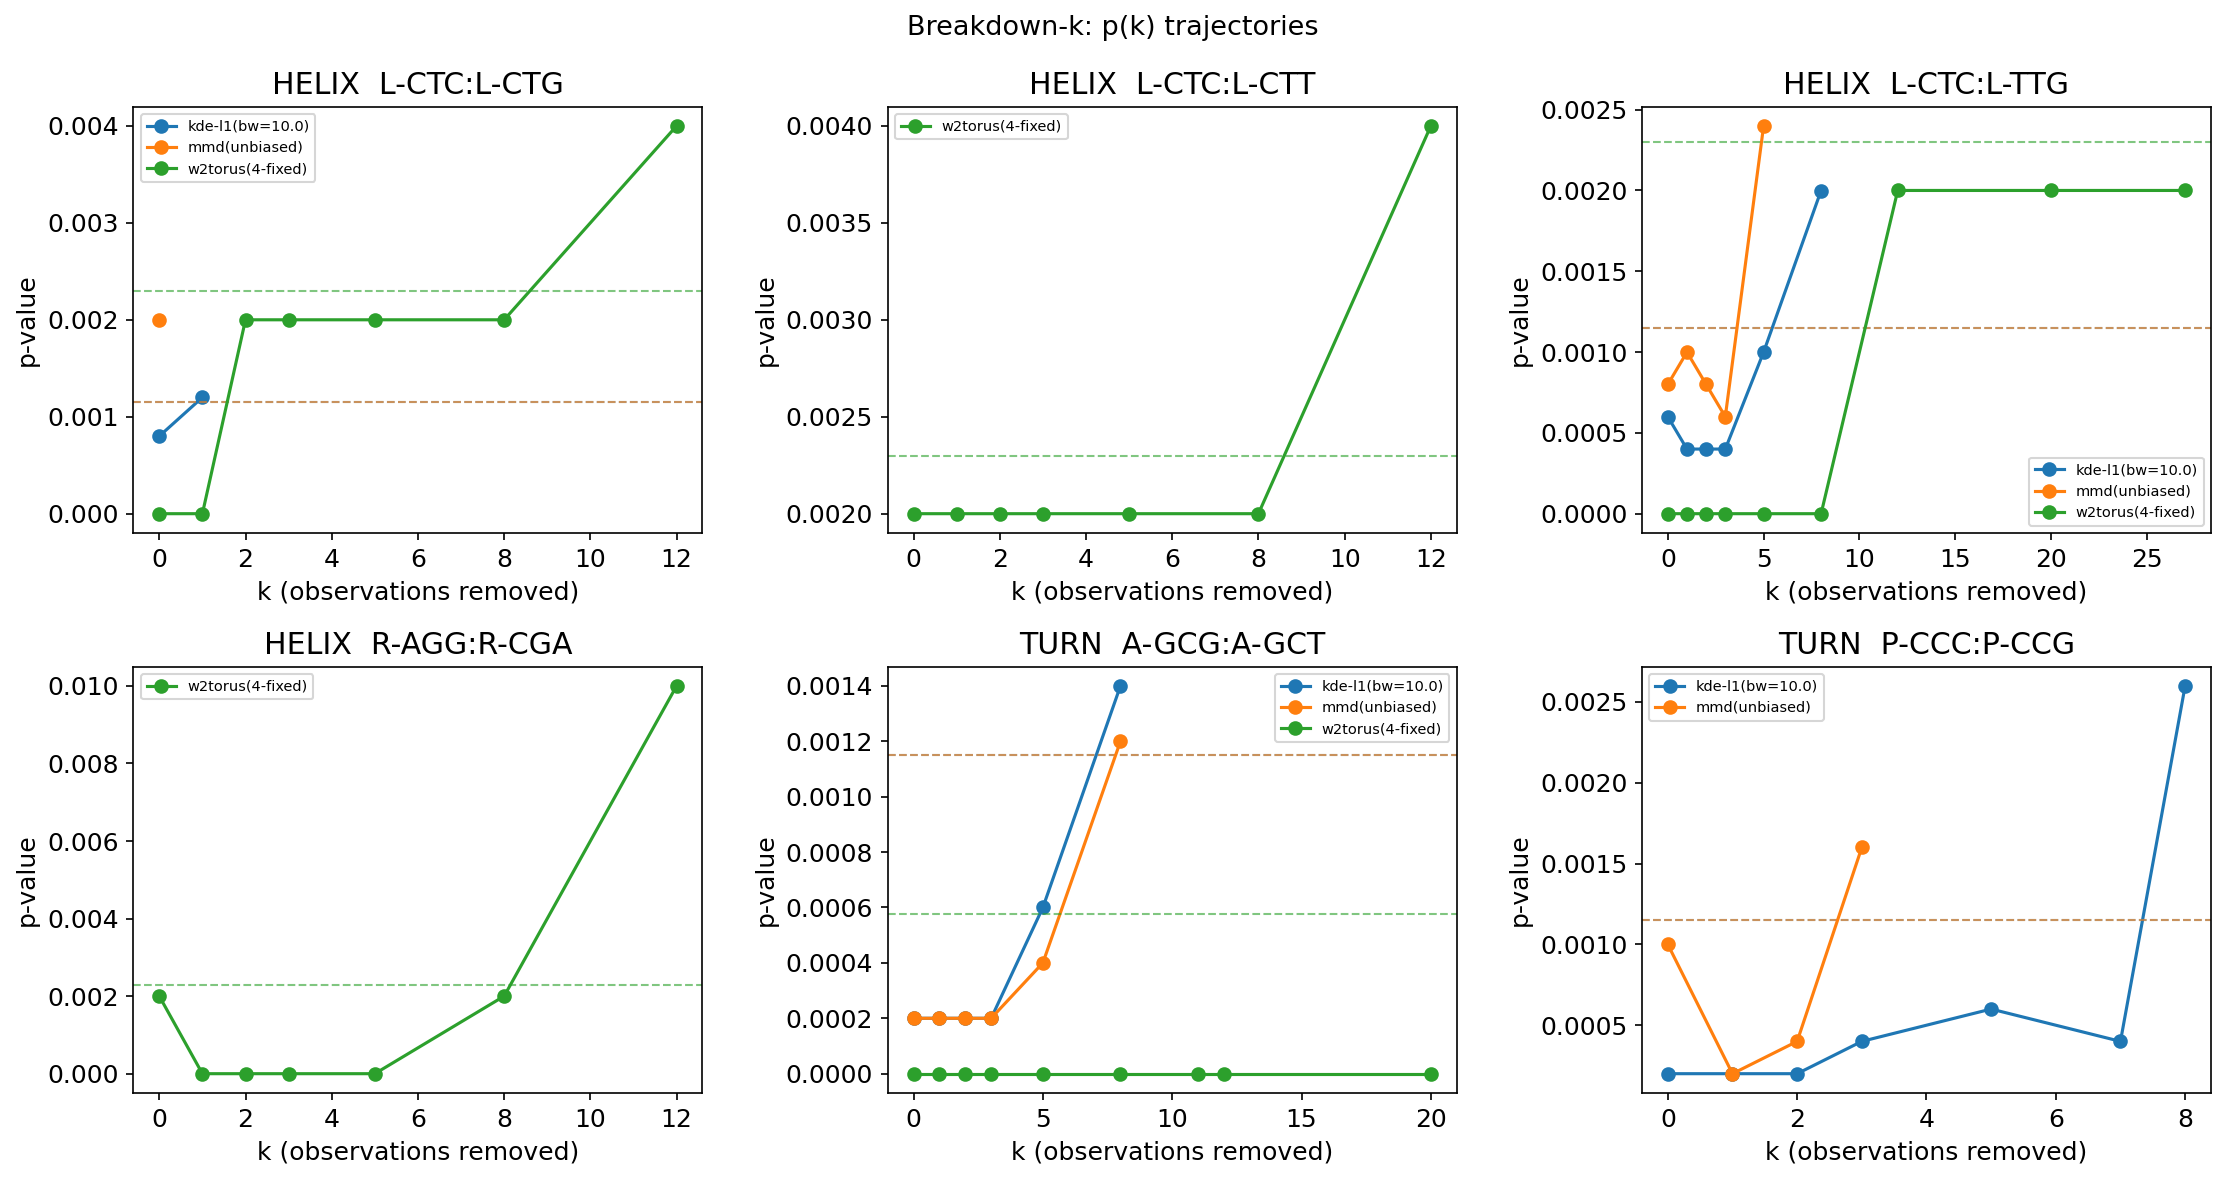

In [65]:
pairs_with_trajectories = sorted({(ss, pair) for (ss, pair, arm) in p_trajectories})

if not pairs_with_trajectories:
    print(
        "No breakdown-k trajectories recorded -- no arm found any candidate pair "
        "significant in this run (or only the cached torus arm did, which has no "
        "per-k trajectory)."
    )
else:
    arm_colors = dict(
        zip(BREAKDOWN_ARMS, sns.color_palette("tab10", n_colors=len(BREAKDOWN_ARMS)))
    )
    ncols = min(3, len(pairs_with_trajectories))
    nrows = int(np.ceil(len(pairs_with_trajectories) / ncols))

    with mpl.style.context(PP5_MPL_STYLE, after_reset=False):
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False
        )
        axes = axes.flatten()

        for ax, (ss, pair) in zip(axes, pairs_with_trajectories):
            for arm in BREAKDOWN_ARMS:
                key = (ss, pair, arm)
                if key not in p_trajectories:
                    continue
                traj = pd.DataFrame(p_trajectories[key])
                color = arm_colors[arm]

                thresh = float(
                    real_rejections.loc[
                        (real_rejections["stat_test"] == arm)
                        & (real_rejections["SS"] == ss),
                        "bh_pvalue_threshold",
                    ].iloc[0]
                )
                row = df_breakdown_all[
                    (df_breakdown_all["SS"] == ss)
                    & (df_breakdown_all["pair"] == pair)
                    & (df_breakdown_all["statistic"] == arm)
                ].iloc[0]
                label = f"{arm}"

                ax.plot(traj["k"], traj["p"], marker="o", color=color, label=label)
                ax.axhline(thresh, color=color, ls="--", lw=1, alpha=0.6)

            # ax.set_yscale("log")
            ax.set_xlabel("k (observations removed)")
            ax.set_ylabel("p-value")
            ax.set_title(f"{ss}  {pair}")
            ax.legend(fontsize=7)

        for ax in axes[len(pairs_with_trajectories) :]:
            ax.set_visible(False)

        fig.suptitle("Breakdown-k: p(k) trajectories", fontsize=13)
        plt.tight_layout()
        fig.savefig(FIGS_OUT_DIR / "r1_breakdown_trajectories.pdf")
        plt.show()

### R2 -- sample-size bias

Spearman(min(n1, n2), ddist) for KDE-L1(bw=10) vs. unbiased MMD-squared, over **all** 87 x 4(SS)
real-data pairs (not just the 6 candidates) -- read directly off `df_all_pvals`, no new
computation. The methodological case for MMD as primary: historically, KDE-L1 shows a strong
negative bias (smaller groups -> larger apparent distance, rho ~ -0.64) while MMD-unbiased does
not (rho ~ +0.04).

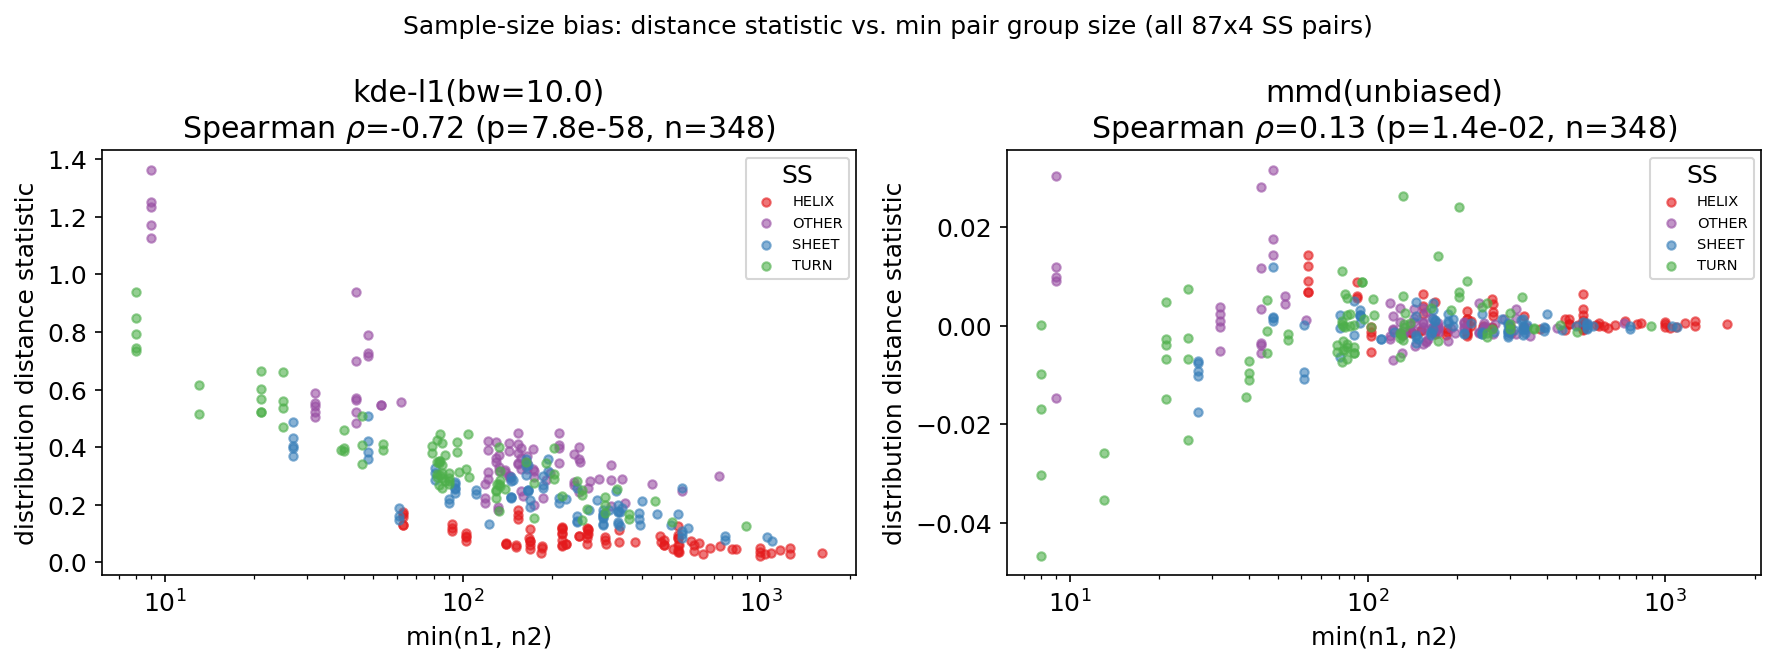

In [66]:
R2_STATS = ["kde-l1(bw=10.0)", "mmd(unbiased)"]

df_r2 = df_all_pvals[
    (df_all_pvals["codon_randomization"] == "none")
    & (df_all_pvals["stat_test"].isin(R2_STATS))
].copy()
df_r2["min_n"] = df_r2[["n1", "n2"]].min(axis=1)

with mpl.style.context(PP5_MPL_STYLE, after_reset=False):
    fig, axes = plt.subplots(1, len(R2_STATS), figsize=(6 * len(R2_STATS), 4.5))
    for ax, stat in zip(axes, R2_STATS):
        sub = df_r2[df_r2["stat_test"] == stat]
        rho, spearman_p = spearmanr(sub["min_n"], sub["ddist"])
        for ss, ss_sub in sub.groupby("condition_group"):
            ax.scatter(
                ss_sub["min_n"],
                ss_sub["ddist"],
                s=16,
                alpha=0.6,
                color=ss_colors.get(ss, "0.4"),
                label=ss,
            )
        ax.set_xscale("log")
        ax.set_xlabel("min(n1, n2)")
        ax.set_ylabel("distribution distance statistic")
        ax.set_title(
            f"{stat}\nSpearman "
            rf"$\rho$={rho:.2f} (p={spearman_p:.1e}, n={len(sub)})"
        )
        ax.legend(fontsize=7, title="SS")

    fig.suptitle(
        "Sample-size bias: distance statistic vs. min pair group size (all 87x4 SS pairs)",
        fontsize=12,
    )
    plt.tight_layout()
    fig.savefig(FIGS_OUT_DIR / "r2_sample_size_bias.pdf")
    plt.show()

### R3 -- breakdown-k heatmap

Heatmap view of the breakdown-k matrix above: color encodes robustness (breakdown-k count,
with a sentinel value above the observed maximum for "robust" pairs that never broke down);
cell text carries the same label as the table (`"n.s."` / `"robust"` / `"not computed"` /
integer k).

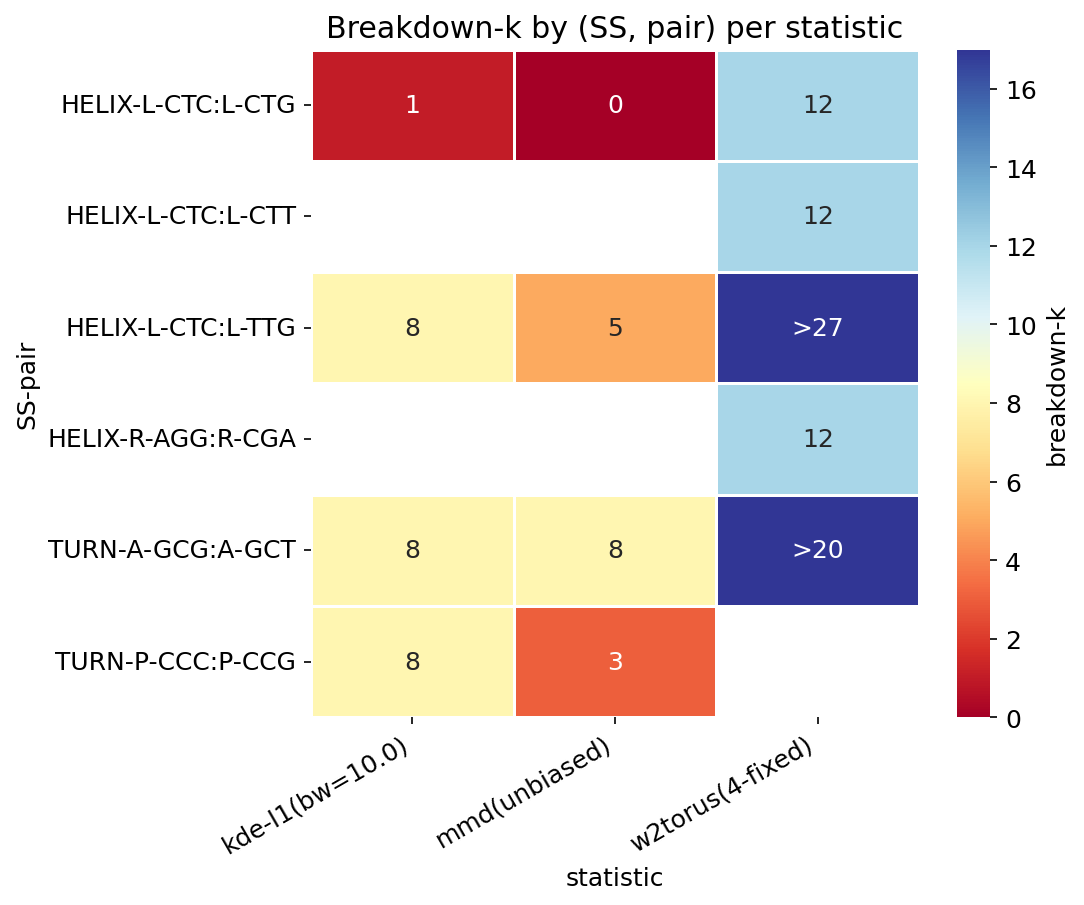

In [67]:
_max_bk = df_breakdown_all["breakdown_k"].max()
_robust_sentinel = (_max_bk if pd.notna(_max_bk) else 0) + 5

_is_sig = df_breakdown_all["significant"].eq(True)
df_breakdown_all["_heatmap_value"] = np.where(
    _is_sig, df_breakdown_all["breakdown_k"].fillna(_robust_sentinel), np.nan
)

mat_color = df_breakdown_all.pivot_table(
    index=["SS", "pair"], columns="statistic", values="_heatmap_value", aggfunc="first"
)
mat_label = df_breakdown_k_matrix.reindex_like(mat_color)

with mpl.style.context(PP5_MPL_STYLE, after_reset=False):
    fig, ax = plt.subplots(
        figsize=(1.8 * mat_color.shape[1] + 2, 0.7 * mat_color.shape[0] + 2)
    )
    sns.heatmap(
        mat_color,
        annot=mat_label.values,
        fmt="",
        cmap="RdYlBu",
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": "breakdown-k"},
    )
    ax.set_title("Breakdown-k by (SS, pair) per statistic")
    # rotate the x-axis labels to avoid overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    plt.tight_layout()
    fig.savefig(FIGS_OUT_DIR / "r3_breakdown_k_heatmap.pdf")
    plt.show()

### R4 -- breakdown-set Ramachandran plot

One panel per SS class with breakdown-set points: background scatter of every point in that
class (from `dataset.csv`), breakdown-set points from `df_breakdown_sets` overlaid on top,
colored by codon. Shows whether adversarially-removed points sit in tight allowed-region
clusters (as expected if they're genuine outliers) rather than scattered broadly across the
background.

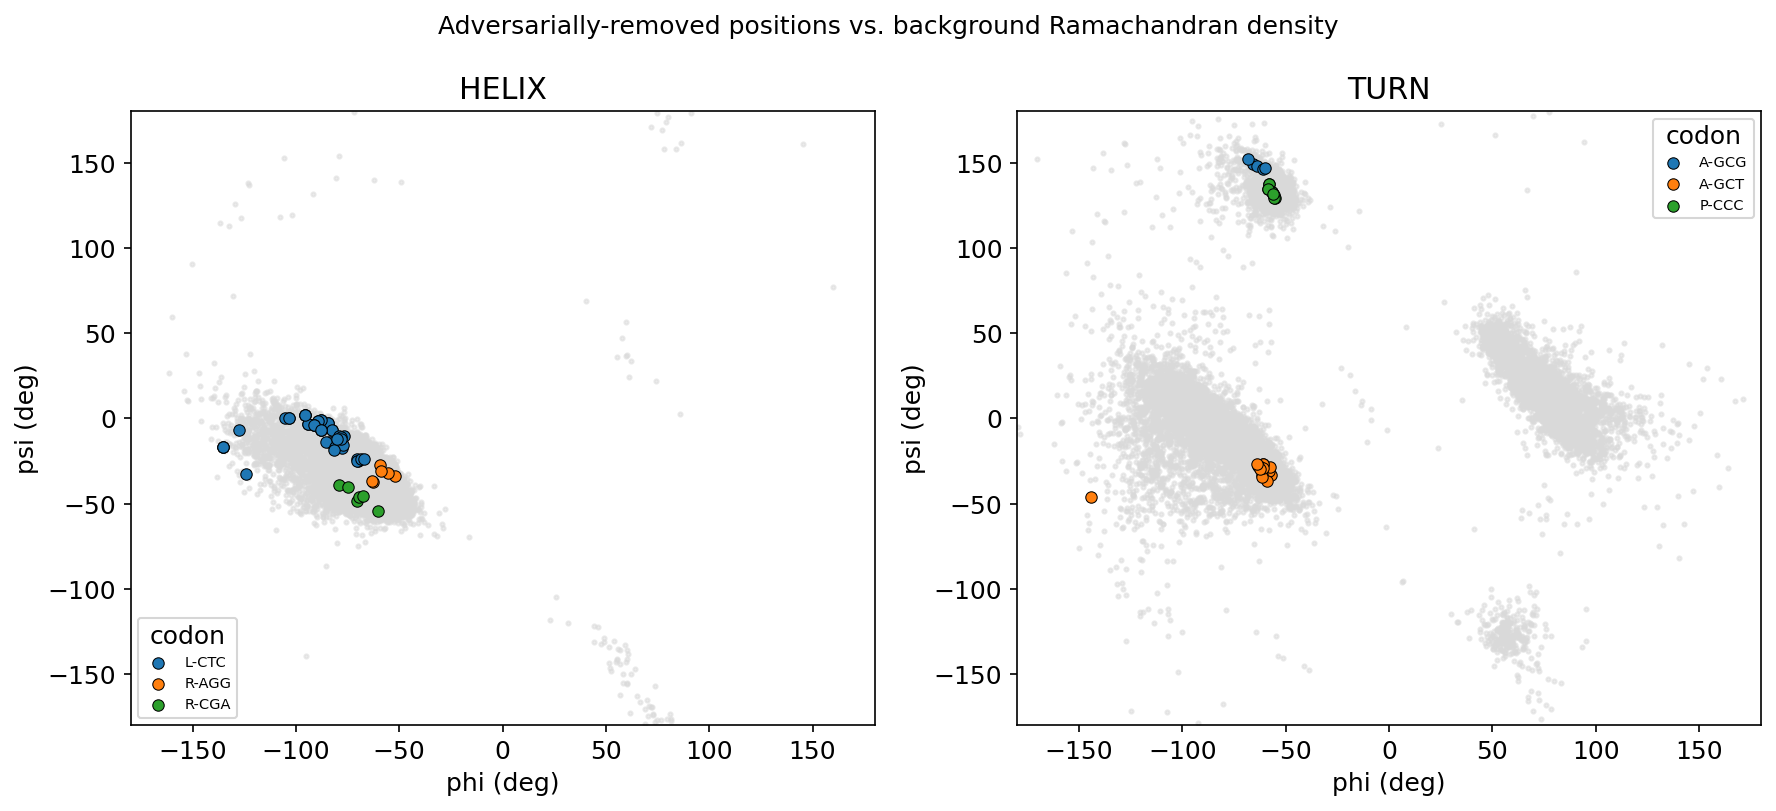

In [68]:
if not len(df_breakdown_sets):
    print("No breakdown-set points to plot (no arm had a finite breakdown-k).")
else:
    ss_classes_present = sorted(df_breakdown_sets["SS"].unique())

    with mpl.style.context(PP5_MPL_STYLE, after_reset=False):
        fig, axes = plt.subplots(
            1,
            len(ss_classes_present),
            figsize=(6 * len(ss_classes_present), 5.5),
            squeeze=False,
        )
        axes = axes[0]

        for ax, ss in zip(axes, ss_classes_present):
            background = df_dataset[df_dataset["condition_group"] == ss]
            ax.scatter(
                background["phi"],
                background["psi"],
                s=4,
                color="0.85",
                alpha=0.5,
                rasterized=True,
            )

            sub = df_breakdown_sets[df_breakdown_sets["SS"] == ss]
            codons = sorted(sub["codon"].unique())
            codon_colors = dict(
                zip(codons, sns.color_palette("tab10", n_colors=len(codons)))
            )
            for codon in codons:
                csub = sub[sub["codon"] == codon]
                ax.scatter(
                    csub["phi_mean"],
                    csub["psi_mean"],
                    s=30,
                    marker="o",
                    color=codon_colors[codon],
                    edgecolor="black",
                    linewidth=0.5,
                    label=codon,
                    zorder=3,
                )

            ax.set_xlim(-180, 180)
            ax.set_ylim(-180, 180)
            ax.set_xlabel("phi (deg)")
            ax.set_ylabel("psi (deg)")
            ax.set_title(ss)
            ax.legend(fontsize=7, title="codon")

        fig.suptitle(
            "Adversarially-removed positions vs. background Ramachandran density",
            fontsize=12,
        )
        plt.tight_layout()
        fig.savefig(FIGS_OUT_DIR / "r4_breakdown_set_ramachandran.pdf")
        plt.show()